## Dropout Method to avoid overfitting

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision 
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [12]:
# Device
device=torch.device(
    "cuda" if torch.cuda.is_available()else "cpu"
)

print(device)

cpu


In [13]:
## Dataset

# Normalize Images
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Load CIFAR-10
train_dataset=torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset=torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [14:47<00:00, 192kB/s]     
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [14]:
## DataLoader
batch_size=128

train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
## Model
class CIFARNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network=nn.Sequential(
            nn.Linear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x=x.view(x.size(0),-1)
        
        return self.network(x)


In [16]:
## Create model
model=CIFARNet().to(device)
print(model)

CIFARNet(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [17]:
## LOSS & Optimizer
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
## Training Loop

epochs = 20

train_losses = []
test_losses = []

train_accs = []
test_accs = []

for epoch in range(epochs):
    
    # Train
    model.train()
    
    running_loss=0
    correct=0
    total=0
    
    for images, labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        
        optimizer.zero_grad()
        
        outputs=model(images)
        loss=criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss+=loss.item()
        
        _, predicted=torch.max(outputs, 1)
        total+=labels.size(0)
        
        correct += (predicted == labels).sum().item()
    
    train_loss=running_loss/len(train_loader)
    
    train_accuracy=100*correct/total
    
    
    ## Validation
    
    model.eval()
    running_loss=0
    correct=0
    total=0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images=images.to(device)
            labels=labels.to(device)
            
            outputs=model(images)
            loss=criterion(outputs, labels)
            running_loss+=loss.item()
            
            _, predicted=torch.max(outputs, 1)
            total+=labels.size(0)
            
            correct+=(predicted==labels).sum().item()
    
    test_loss=running_loss/len(test_loader)
    test_accuracy=100*correct/total
        
    # SAVE HISTORY

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_accuracy)
    test_accs.append(test_accuracy)

    # PRINT
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Test Acc: {test_accuracy:.2f}%"
    )
    


    

Epoch [1/20] | Train Loss: 1.7152 | Test Loss: 1.4975 | Train Acc: 100.00% | Test Acc: 47.11%
Epoch [2/20] | Train Loss: 1.5143 | Test Loss: 1.3984 | Train Acc: 100.00% | Test Acc: 50.03%
Epoch [3/20] | Train Loss: 1.4271 | Test Loss: 1.3587 | Train Acc: 100.00% | Test Acc: 51.32%
Epoch [4/20] | Train Loss: 1.3637 | Test Loss: 1.3233 | Train Acc: 100.00% | Test Acc: 52.34%
Epoch [5/20] | Train Loss: 1.3145 | Test Loss: 1.3033 | Train Acc: 100.00% | Test Acc: 53.38%
Epoch [6/20] | Train Loss: 1.2675 | Test Loss: 1.2831 | Train Acc: 100.00% | Test Acc: 53.82%
Epoch [7/20] | Train Loss: 1.2327 | Test Loss: 1.2606 | Train Acc: 100.00% | Test Acc: 54.93%
Epoch [8/20] | Train Loss: 1.1891 | Test Loss: 1.2365 | Train Acc: 100.00% | Test Acc: 56.33%
Epoch [9/20] | Train Loss: 1.1613 | Test Loss: 1.2331 | Train Acc: 100.00% | Test Acc: 56.03%
Epoch [10/20] | Train Loss: 1.1289 | Test Loss: 1.2385 | Train Acc: 100.00% | Test Acc: 55.93%
Epoch [11/20] | Train Loss: 1.1042 | Test Loss: 1.1966 | Tr

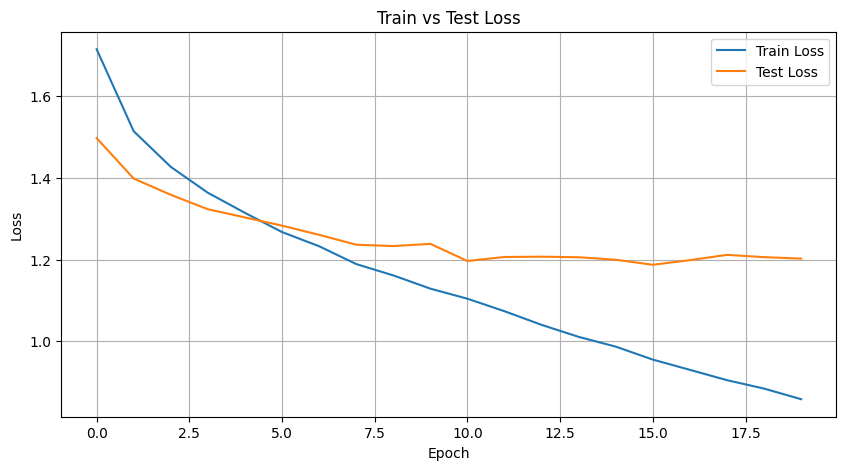

In [20]:
### Loss Comparison Graph
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses, label="Train Loss"
)

plt.plot(
    test_losses, label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

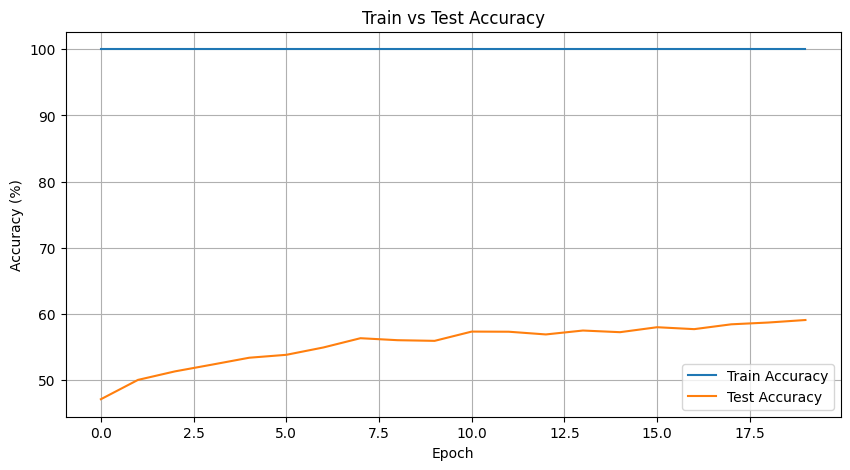

In [21]:
## Accuracy Comparison
plt.figure(figsize=(10,5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    test_accs,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy")

plt.legend()

plt.grid(True)

plt.show()